# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Step 2: Load the Dataset

In [2]:
df = pd.read_csv('../../data/raw/fraudTest.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


# Step 3: Data Preprocessing

In [3]:
# Check for missing values
print(df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


No missing values /

In [4]:
# Summary statistics for the 'amt' column because it is the only numerical value here
print(df['amt'].describe())

count    555719.000000
mean         69.392810
std         156.745941
min           1.000000
25%           9.630000
50%          47.290000
75%          83.010000
max       22768.110000
Name: amt, dtype: float64


So, we are dealing with amount of money from 1 to 22,768 usd(s) with other descriptive statistics

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

Checking the info of this dataframe

# Understanding the dataset
### 1. There are 555,719 rows of data (entries)
### 2. There are 23 columns. Mainly about bank transactions
#### 2.1 Purely Transaction Related columns:
  * trans_date_trans_time --> Timestamp of each data row
  * merchant --> business names where transaction happened
  * category --> what kind of service
  * amt --> Amount in each transaction (Float)
  * trans_num --> unique id of each transaction
  * unix_time --> Similar to timestamp but with UNIX system where It’s the number of seconds since the start of 1. January 1970 UTC.
  * merch_lat --> Latitude of business/transaction?
  * merch_long --> Longtitude of business/transaction?
  * is_fraud --> Our Target! 1= True, it is a fraud transation. 0 = No,it is a normal transaction
#### 2.2 Biographic of customers
  * first --> Firstname, which may not any impact on the analysis
  * last  --> Lastname, which may not any impact on the analysis
  * gender --> Binary values. F : Female, M : Male
  * street --> String
  * city --> String
  * state --> States in USA
  * zip   --> Zipcode
  * lat --> Latitude of customer address?
  * long--> Longtitude of customer address?
  * city_pop --> City Population?
  * job --> Categorical
  * dob --> Date of Birth
### 3.Unneccessary columns for analysis
* Unnamed: 0 --> Dupplicate id as python already provide
* first --> First name doesn't matter
* last --> Also as Last name
So, I'll drop them three.

### 4.Columns I don't understand 
* cc_num

# Step 5: Exploratory Data Analysis (EDA)

## 1. Is the data balance?

In [6]:
# Calculate the total number of transactions
total_transactions = df['is_fraud'].count()

# Count the occurrences of each value in the is_fraud column
fraud_counts = df['is_fraud'].value_counts().reset_index()
fraud_counts.columns = ['is_fraud', 'count']

# Calculate the number of fraudulent transactions
fraudulent_transactions = fraud_counts.loc[fraud_counts['is_fraud'] == 1, 'count'].values[0]

# Calculate the percentage of fraudulent transactions
fraudulent_percentage = (fraudulent_transactions / total_transactions) * 100
print(f"Percentage of fraudulent transactions: {fraudulent_percentage:.2f}%")

Percentage of fraudulent transactions: 0.39%


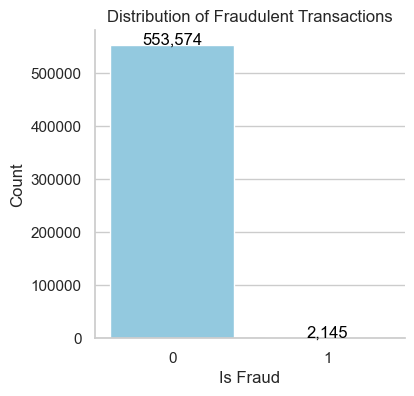

In [7]:


# Create a bar plot
plt.figure(figsize=(4, 4))
sns.set(style="whitegrid")
sns.barplot(x='is_fraud', y='count', data=fraud_counts, palette=['skyblue', 'salmon'])

# Annotate the bars with the count values formatted with commas
for index, row in fraud_counts.iterrows():
    plt.text(row.name, row['count'], f'{row["count"]:,}', color='black', ha="center")

# Set the title and labels
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')

# Remove the top and right spines
sns.despine()

# Show the plot
plt.show()


The bar chart effectively show us that our dataset is highly imbalanced with 2,145 fraudulent cases in 555,719 transaction (0.39%)

## 2. Distribution of Transactions amount

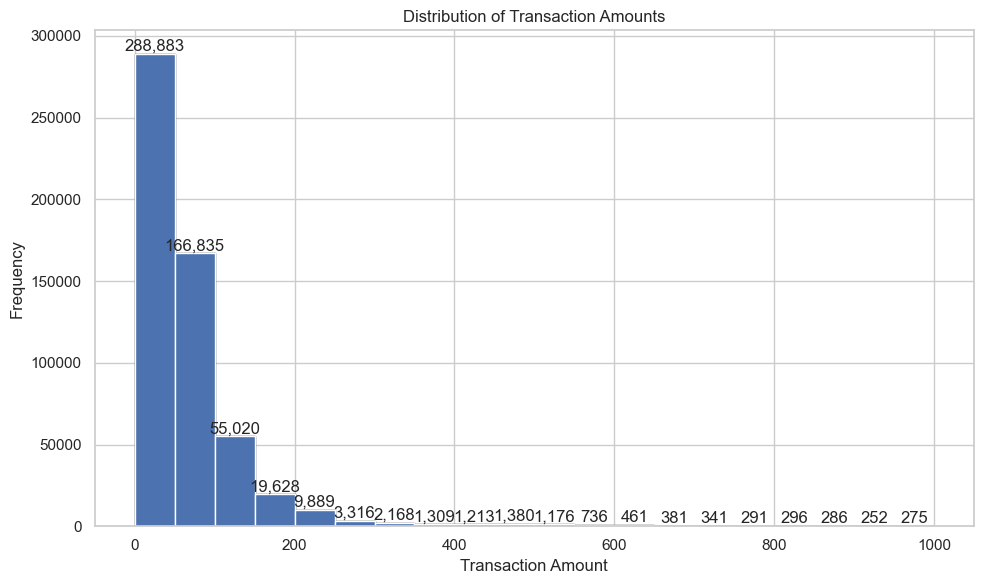

In [8]:
import matplotlib.pyplot as plt

# Define the intervals
intervals = [i for i in range(0, 1001, 50)]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['amt'], bins=intervals, color='skyblue', edgecolor='black')

# Annotate each bar with its formatted frequency value
for i, freq in enumerate(plt.hist(df['amt'], bins=intervals)[0]):
    plt.text(intervals[i] + (intervals[i+1] - intervals[i])/2, freq, '{:,}'.format(int(freq)), ha='center', va='bottom')

# Set the title and labels
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


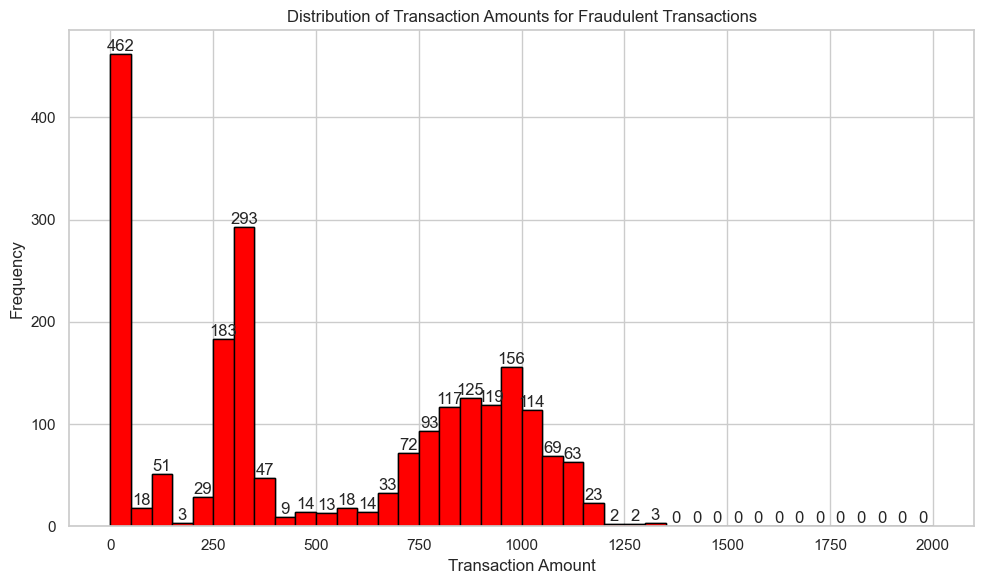

In [9]:
import matplotlib.pyplot as plt

# Define the intervals
intervals = [i for i in range(0, 2001, 50)]

# Filter the DataFrame for fraudulent transactions
fraudulent_data = df[df['is_fraud'] == 1]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(fraudulent_data['amt'], bins=intervals, color='red', edgecolor='black')

# Annotate each bar with its formatted frequency value
for i, freq in enumerate(plt.hist(fraudulent_data['amt'], bins=intervals, color='red', edgecolor='black')[0]):
    plt.text(intervals[i] + (intervals[i+1] - intervals[i])/2, freq, '{:,}'.format(int(freq)), ha='center', va='bottom')

# Set the title and labels
plt.title('Distribution of Transaction Amounts for Fraudulent Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


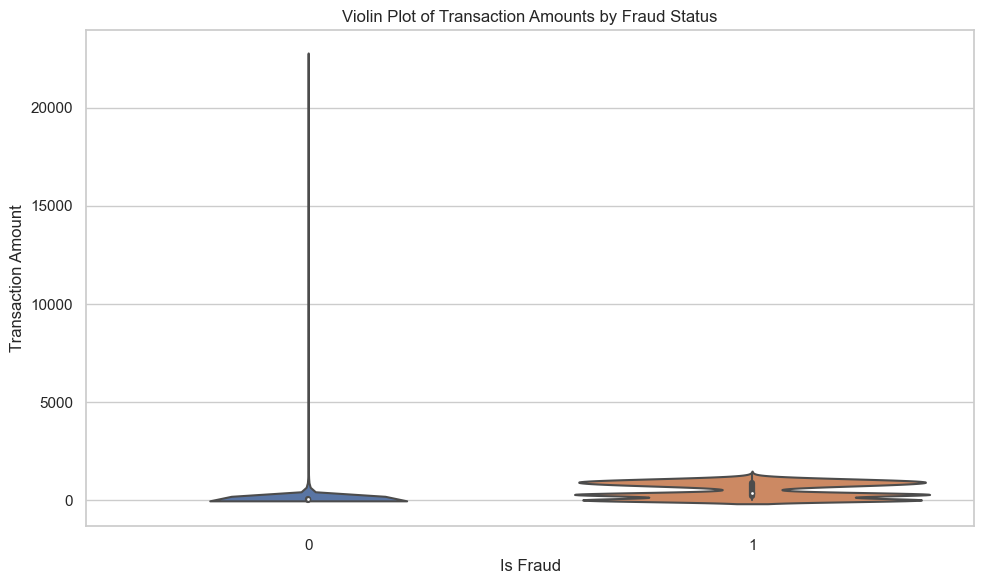

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 0 and is_fraud = 1)
fraudulent_data = df[df['is_fraud'].isin([0, 1])]

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_fraud', y='amt', data=fraudulent_data)

# Set the title and labels
plt.title('Violin Plot of Transaction Amounts by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


The violin chart clearly shows us that normal Transaction amount data has outlier

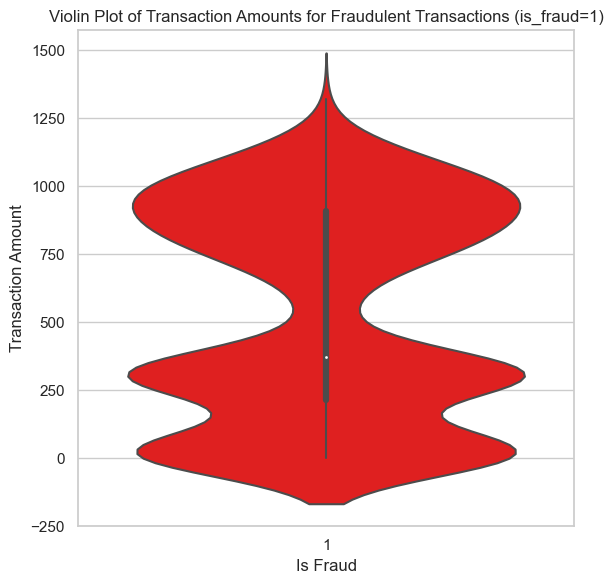

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Create the violin plot for fraudulent transactions only
plt.figure(figsize=(6, 6))
sns.violinplot(x=fraudulent_data['is_fraud'], y=fraudulent_data['amt'], color='red')

# Set the title and labels
plt.title('Violin Plot of Transaction Amounts for Fraudulent Transactions (is_fraud=1)')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


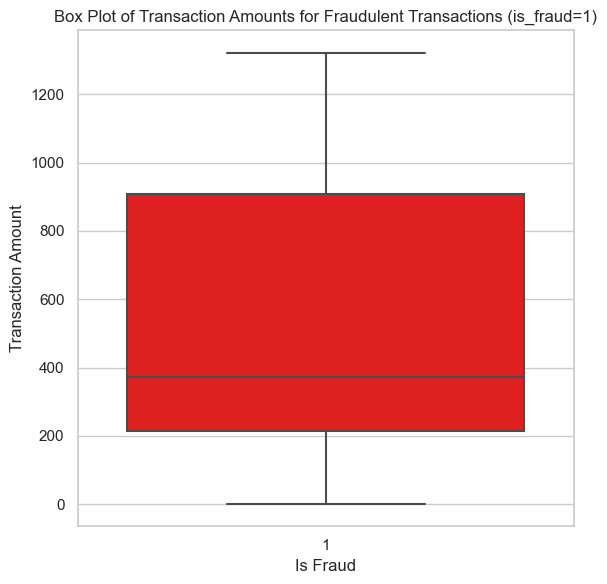

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Create the box plot for fraudulent transactions only
plt.figure(figsize=(6, 6))
sns.boxplot(x=fraudulent_data['is_fraud'], y=fraudulent_data['amt'], color='red')

# Set the title and labels
plt.title('Box Plot of Transaction Amounts for Fraudulent Transactions (is_fraud=1)')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


When it comes to Fraud data it seems to be more consistent with specific amount 

In [13]:
# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Calculate descriptive statistics for the 'amt' column
descriptive_stats = fraudulent_data['amt'].describe()

# Round the descriptive statistics to two decimal places
descriptive_stats_rounded = descriptive_stats.round(2)

# Print the rounded descriptive statistics
print(descriptive_stats_rounded)


count    2145.00
mean      528.36
std       392.75
min         1.78
25%       214.51
50%       371.94
75%       907.77
max      1320.92
Name: amt, dtype: float64


In [14]:
# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Calculate the frequency of each value in the 'amt' column for fraudulent transactions
amt_value_counts = fraudulent_data['amt'].value_counts()

# Select the top 5 modes along with their frequencies
top5_modes_with_frequency = amt_value_counts.head(5)

# Print the top 5 modes with their frequencies
print("Top 5 modes of 'amt' for fraudulent transactions and their frequencies:")
print(top5_modes_with_frequency)


Top 5 modes of 'amt' for fraudulent transactions and their frequencies:
7.99     3
10.00    3
21.55    3
9.41     2
21.88    2
Name: amt, dtype: int64


Seems like there is no popular amount for fraud data

## 3.What is the distribution of transaction categories?

In [15]:
# Count the occurrences of each transaction category
category_counts = df['category'].value_counts()

# Calculate the proportion of transactions in each category
category_proportions = category_counts / len(df) * 100  # Calculate percentages

# Print the distribution of transaction categories
print("Distribution of Transaction Categories:")
for category, count in category_counts.items():
    proportion = category_proportions[category]
    print(f"- {category}: {count} transactions ({proportion:.2f}%)")


Distribution of Transaction Categories:
- gas_transport: 56370 transactions (10.14%)
- grocery_pos: 52553 transactions (9.46%)
- home: 52345 transactions (9.42%)
- shopping_pos: 49791 transactions (8.96%)
- kids_pets: 48692 transactions (8.76%)
- shopping_net: 41779 transactions (7.52%)
- entertainment: 40104 transactions (7.22%)
- personal_care: 39327 transactions (7.08%)
- food_dining: 39268 transactions (7.07%)
- health_fitness: 36674 transactions (6.60%)
- misc_pos: 34574 transactions (6.22%)
- misc_net: 27367 transactions (4.92%)
- grocery_net: 19426 transactions (3.50%)
- travel: 17449 transactions (3.14%)


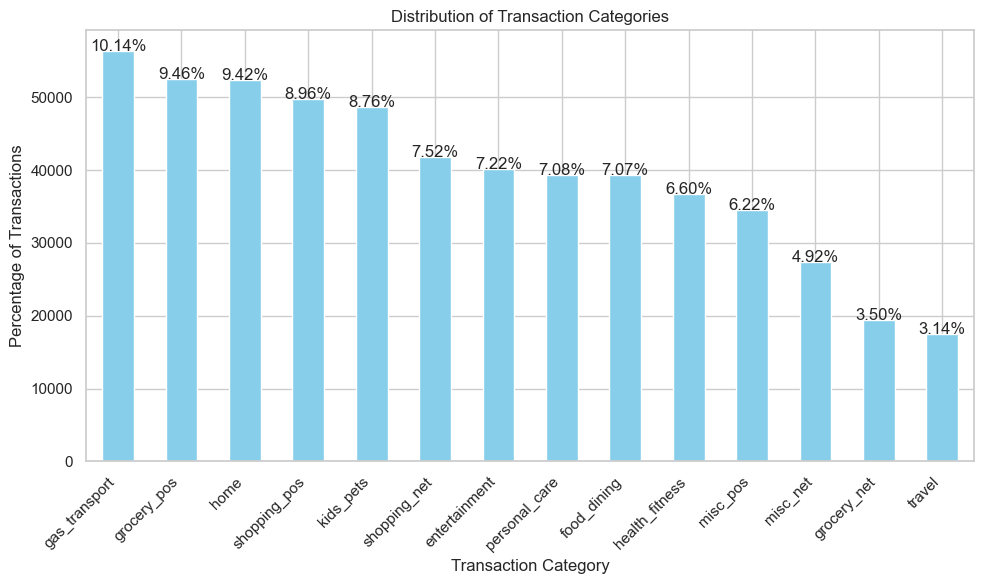

In [16]:
import matplotlib.pyplot as plt

# Plot the bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')

# Set the title and labels
plt.title('Distribution of Transaction Categories')
plt.xlabel('Transaction Category')
plt.ylabel('Percentage of Transactions')

# Display the percentages on top of the bars
for i, count in enumerate(category_counts):
    plt.text(i, count + 0.5, f'{category_proportions[i]:.2f}%', ha='center')

# Show the plot
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4.Is there any correlation between transaction amount and whether it is a fraudulent transaction?

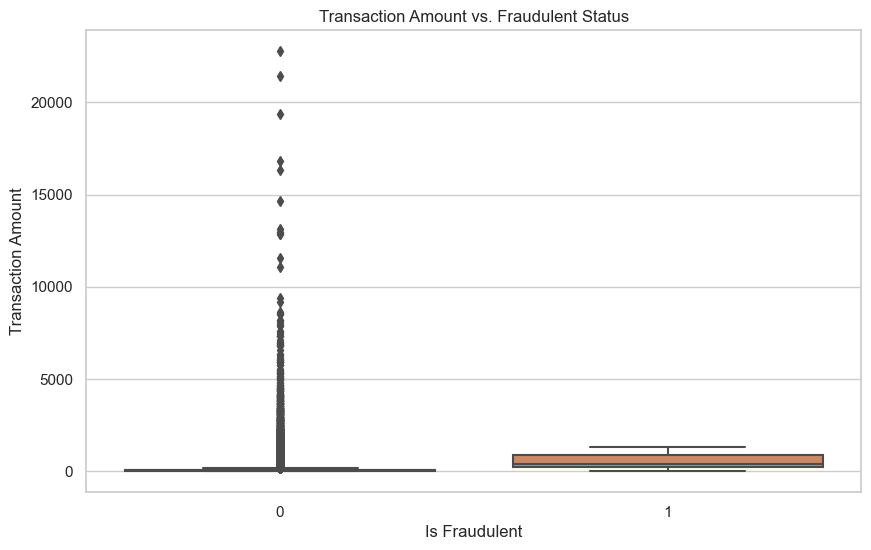

Correlation coefficient between transaction amount and fraudulent status: 0.18226707130820377


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot or box plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Transaction Amount vs. Fraudulent Status')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.show()

# Calculate Pearson correlation coefficient
correlation_coefficient = df['amt'].corr(df['is_fraud'])

# Print the correlation coefficient
print("Correlation coefficient between transaction amount and fraudulent status:", correlation_coefficient)


0.18 seems to be a poor correlation

## 5. What is the distribution of fraudulent transactions over time (e.g., by month, day of the week, hour)?

The data runfrom 21/06/2020 - 31/12/2020

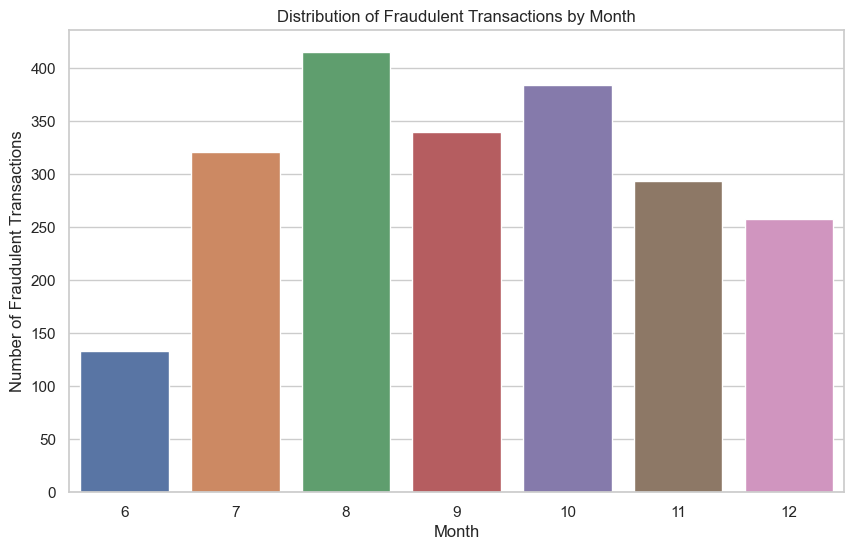

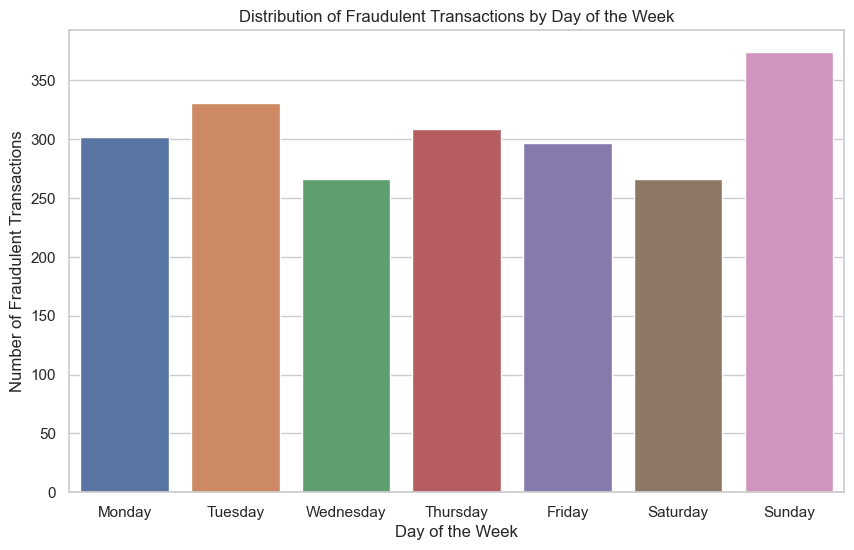

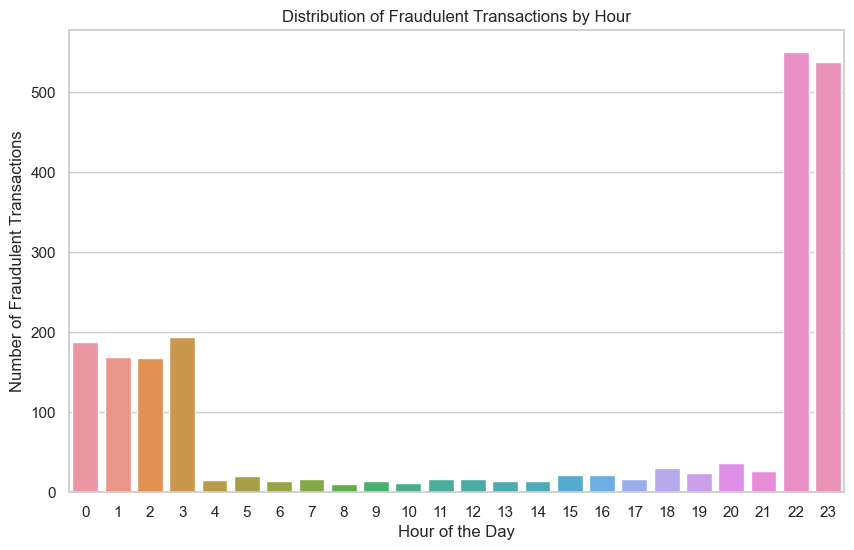

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'trans_date_trans_time' column to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract date components
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['hour'] = df['trans_date_trans_time'].dt.hour

# Filter fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Plot the distribution of fraudulent transactions by month
plt.figure(figsize=(10, 6))
sns.countplot(x='month', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

# Plot the distribution of fraudulent transactions by day of the week
plt.figure(figsize=(10, 6))
sns.countplot(x='day_of_week', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

# Plot the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


## 6. What are the most common occupations among individuals involved in fraudulent transactions?

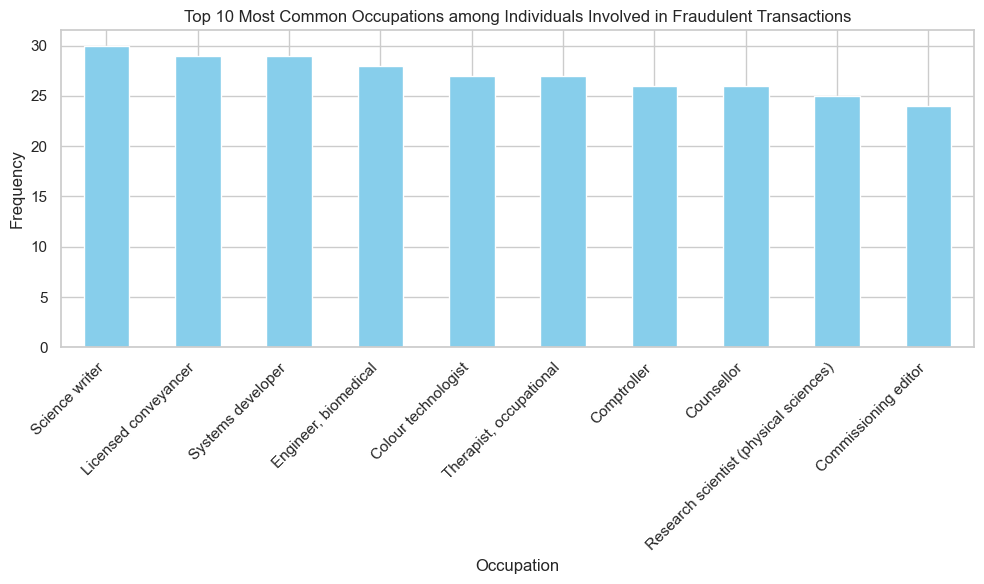

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of each occupation
occupation_counts = fraudulent_transactions['job'].value_counts()

# Visualize the distribution of occupations
plt.figure(figsize=(10, 6))
occupation_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Occupations among Individuals Involved in Fraudulent Transactions')
plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


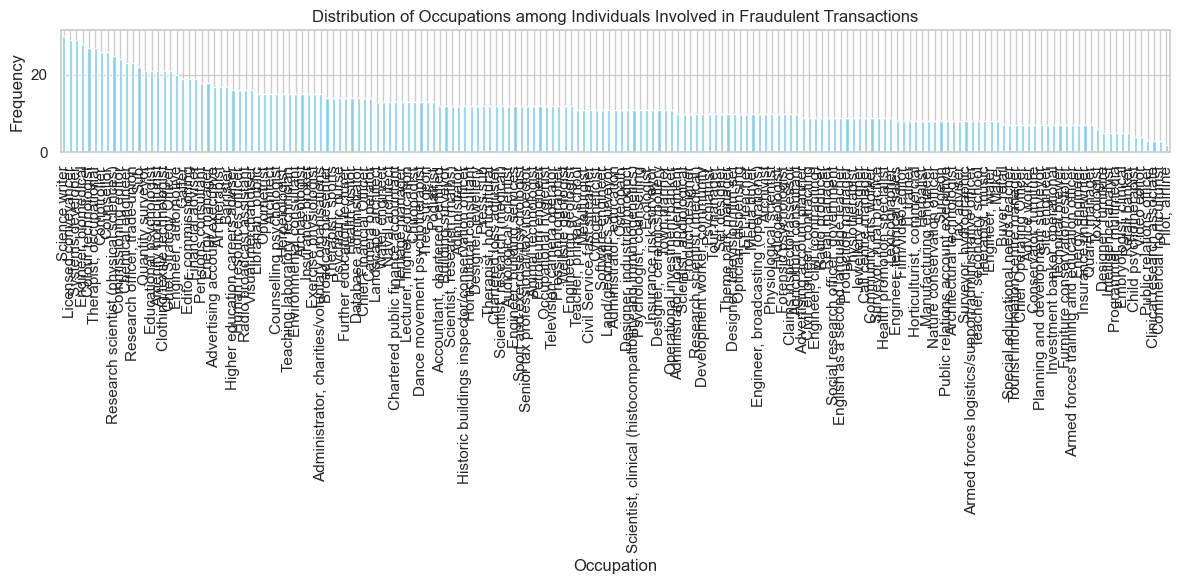

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of each occupation
occupation_counts = fraudulent_transactions['job'].value_counts()

# Visualize the distribution of occupations
plt.figure(figsize=(12, 6))
occupation_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Occupations among Individuals Involved in Fraudulent Transactions')
plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()


We need to clran this data ex.Mapping to see better result of this distribution

## 7.Are fraudulent transactions more common in certain states or cities?

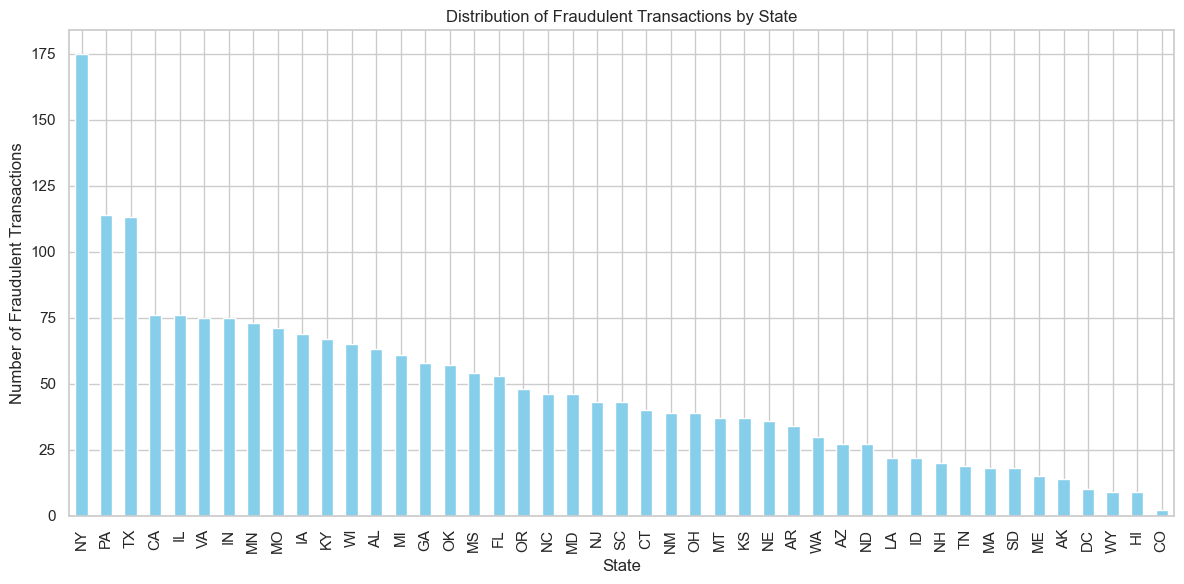

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of fraudulent transactions by state
state_counts = fraudulent_transactions['state'].value_counts()

# Visualize the distribution of fraudulent transactions by state
plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Fraudulent Transactions by State')
plt.xlabel('State')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

We can do this in TableU for better understanding

AL: Alabama
AK: Alaska
AZ: Arizona
AR: Arkansas
CA: California
CO: Colorado
CT: Connecticut
DE: Delaware
FL: Florida
GA: Georgia
HI: Hawaii
ID: Idaho
IL: Illinois
IN: Indiana
IA: Iowa
KS: Kansas
KY: Kentucky
LA: Louisiana
ME: Maine
MD: Maryland
MA: Massachusetts
MI: Michigan
MN: Minnesota
MS: Mississippi
MO: Missouri
MT: Montana
NE: Nebraska
NV: Nevada
NH: New Hampshire
NJ: New Jersey
NM: New Mexico
NY: New York
NC: North Carolina
ND: North Dakota
OH: Ohio
OK: Oklahoma
OR: Oregon
PA: Pennsylvania
RI: Rhode Island
SC: South Carolina
SD: South Dakota
TN: Tennessee
TX: Texas
UT: Utah
VT: Vermont
VA: Virginia
WA: Washington
WV: West Virginia
WI: Wisconsin
WY: Wyoming

## 8.What is the average population size of cities where fraudulent transactions occur?

In [22]:
# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Aggregate population size by city
city_population_avg = fraudulent_transactions.groupby('city')['city_pop'].mean()

# Calculate the average population size of cities
average_population_size = city_population_avg.mean()

# Print the average population size
print("Average population size of cities where fraudulent transactions occur:", average_population_size)


Average population size of cities where fraudulent transactions occur: 61504.42874074074


## 9.Do fraudulent transactions tend to occur more frequently during certain times of the day?

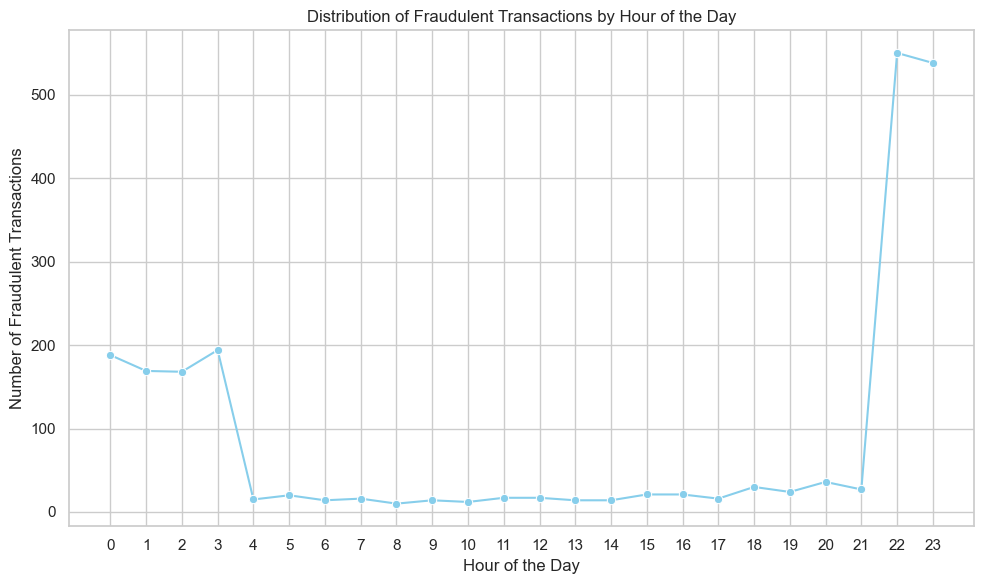

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1].copy()  # Make a copy to avoid modifying the original DataFrame

# Use .loc to set values in the DataFrame explicitly
fraudulent_transactions.loc[:, 'hour'] = fraudulent_transactions['trans_date_trans_time'].dt.hour

# Aggregate transactions by hour of the day
fraudulent_transactions_by_hour = fraudulent_transactions.groupby('hour').size()

# Visualize the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
sns.lineplot(x=fraudulent_transactions_by_hour.index, y=fraudulent_transactions_by_hour.values, marker='o', color='skyblue')
plt.title('Distribution of Fraudulent Transactions by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


Seems like at 10 pm is the most occues fraudulants

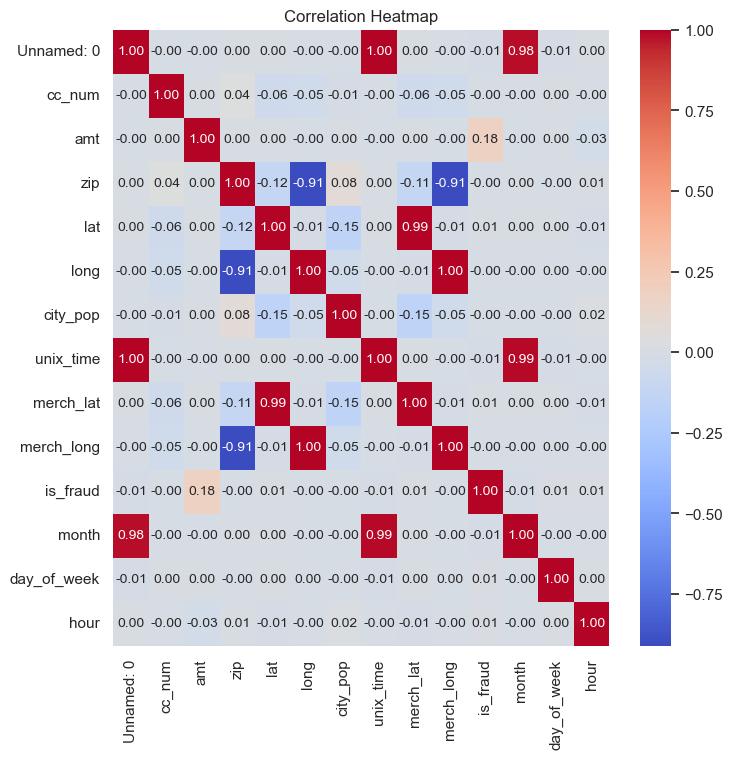

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Heatmap')
plt.show()
